In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
import leidenalg
import squidpy as sq
from scipy import sparse
from matplotlib.colors import ListedColormap
import os
import numpy as np
import pandas as pd
from scipy.spatial import KDTree
from tqdm import tqdm
import seaborn as sns
import geopandas as gpd
from scipy.io import mmread
from scipy.spatial.distance import pdist
from scipy.stats import entropy
from scipy.stats import norm

In [2]:
import os
import numpy as np
import pandas as pd
from collections import defaultdict
from scipy.spatial import KDTree
from tqdm import tqdm
import anndata

def compute_tsps(adata, cell_type_col="tumor_state", spatial_key="spatial", radius=500):
    """
    Compute the Tumor State Proximity Score (TSPS) for each tumor cell.

    Parameters:
        adata: AnnData
            AnnData object with spatial coordinates and tumor state labels.
        cell_type_col: str
            Column in `adata.obs` with tumor state.
        spatial_key: str
            Key in `adata.obsm` with spatial coordinates.
        radius: float
            Radius to define neighbors.

    Returns:
        tsps_per_cell: np.ndarray
            TSPS value for each cell in the same order as `adata.obs`.
    """
    if spatial_key not in adata.obsm:
        raise ValueError(f"Spatial key '{spatial_key}' not found in `adata.obsm`.")
    if cell_type_col not in adata.obs:
        raise ValueError(f"Cell type column '{cell_type_col}' not found in `adata.obs`.")

    coords = adata.obsm[spatial_key]
    tumor_states = adata.obs[cell_type_col].values
    kd_tree = KDTree(coords)

    tsps_per_cell = np.zeros(len(coords))

    for i in tqdm(range(len(coords)), desc="Computing per-cell TSPS"):
        neighbors_idx = kd_tree.query_ball_point(coords[i], radius)
        neighbors_idx = [j for j in neighbors_idx if j != i]

        if len(neighbors_idx) > 0:
            same_state_count = sum(tumor_states[j] == tumor_states[i] for j in neighbors_idx)
            tsps_per_cell[i] = same_state_count / len(neighbors_idx)
        else:
            tsps_per_cell[i] = np.nan

    return tsps_per_cell

# ---- Main Aggregation Loop ----

# Initialize
all_tsps = defaultdict(list)

# Set working directory
os.chdir('/home/fceccarelli/home3/OT_simulation/code/VisiumHD/segmentation')
folders = [x for x in os.listdir() if os.path.isdir(x)]
folders.sort()

for folder in folders:
    print(f"Processing patient: {folder}")
    try:
        adata = anndata.read_h5ad(folder + "/" + folder + "_008_programs.h5ad")
    except:
        print(f"Error reading {folder}")
        continue

    # Keep only tumor cells
    adata = adata[adata.obs["cell_type"].str.startswith("MP"), :]

    # Compute TSPS per cell
    tsps_per_cell = compute_tsps(adata, cell_type_col="cell_type")

    # Pool per-cell TSPS by tumor state
    for state in np.unique(adata.obs["cell_type"]):
        indices = np.where(adata.obs["cell_type"].values == state)[0]
        all_tsps[state].extend(tsps_per_cell[indices])

# ---- Compute Global Mean TSPS per State ----

global_mean_tsps = {
    state: np.nanmean(tsps_values) for state, tsps_values in all_tsps.items()
}
global_std_tsps = {
    state: np.nanstd(tsps_values) for state, tsps_values in all_tsps.items()
}
global_counts = {
    state: np.sum(~np.isnan(tsps_values)) for state, tsps_values in all_tsps.items()
}

# Create DataFrame
pooled_df = pd.DataFrame({
    "global_mean_tsps": pd.Series(global_mean_tsps),
    "global_std_tsps": pd.Series(global_std_tsps),
    "n_cells": pd.Series(global_counts)
}).sort_values("global_mean_tsps", ascending=False)

# Display
print(pooled_df)

Processing patient: Pat03_W0


Computing per-cell TSPS: 100%|██████████| 186/186 [00:00<00:00, 809.63it/s]


Processing patient: Pat03_W4


Computing per-cell TSPS: 100%|██████████| 18131/18131 [00:16<00:00, 1124.75it/s]


Processing patient: Pat06_W0


...

Processing patient: Pat2_W12


Computing per-cell TSPS: 100%|██████████| 34401/34401 [00:45<00:00, 763.81it/s] 


Processing patient: Pat2_W4


Computing per-cell TSPS: 100%|██████████| 19322/19322 [00:15<00:00, 1234.18it/s]


      global_mean_tsps  global_std_tsps  n_cells
MP_4          0.344699         0.162496    12266
MP_7          0.344559         0.274662    55474
MP_3          0.315762         0.150370    76578
MP_6          0.306576         0.167676    72479
MP_1          0.304272         0.235321    60786
MP_5          0.284491         0.153817    45278
MP_2          0.176672         0.082160    43323


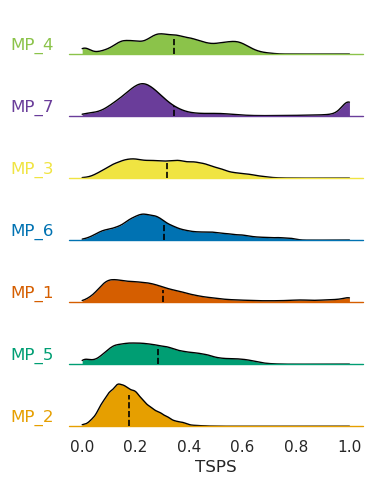

In [22]:
cell_type_colors = {
    "B cells": "#e91e63",
    "Plasma cells": "#ce93d8",
    "T cells - CD4": "#673ab7",
    "T cells - CD4 Tcm": "#8B96D2",
    "T cells - CD8": "#61ABEC",
    "T cells - CD8 Tcm": "#02c1cf",
    "T cells - Exhausted T cell": "#BFEAEF",
    "T cells - Tregs": "#007991",
    "M1 macrophages": "#388e3c",
    "M2 macrophages": "#8bc34a",
    "iCAF": "#cddc39",
    "myoCAF": "#ffeb3b",
    "Endothelial cells": "#ffa407",
    "Keratinocytes": "#ff7043",
    "Malignant": "firebrick",
    "Cycling cells": "grey80",
    'MP_1': "#D55E00",
    'MP_2': "#E69F00",
    'MP_3': "#F0E442",
    'MP_4': "#8BC34A",
    'MP_5': "#009E73",
    'MP_6': "#0072B2",
    'MP_7': "#6A3D9A",
    "T cells": "#007991",
    "Macrophages": "#8bc34a",
    "CAF": "#ffeb3b",
}

def plot_tsps_ridgeplot(all_tsps, cell_type_colors, min_cells=10):
    """
    Create a ridge (joy) plot of TSPS distributions per tumor state,
    showing mean TSPS with line height matching the density peak,
    and ordering rows by mean TSPS (descending).
    """
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde
    import numpy as np

    # Build clean dataframe
    records = []
    for state, values in all_tsps.items():
        clean_values = [v for v in values if not pd.isna(v)]
        if len(clean_values) >= min_cells:
            records.extend([(state, v) for v in clean_values])
    df = pd.DataFrame(records, columns=["tumor_state", "TSPS"])

    # Compute mean TSPS per state and sort
    mean_tsps = df.groupby("tumor_state")["TSPS"].mean()
    sorted_states = mean_tsps.sort_values(ascending=False).index.tolist()

    # Filter palette
    palette = {s: cell_type_colors[s] for s in sorted_states if s in cell_type_colors}

    # Set seaborn style
    sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

    # Ridge plot
    g = sns.FacetGrid(
        df,
        row="tumor_state",
        hue="tumor_state",
        aspect=6,
        height=0.7,
        palette=palette,
        row_order=sorted_states
    )

    # Filled density
    g.map(sns.kdeplot, "TSPS", bw_adjust=0.8, clip=(0, 1),
          fill=True, alpha=1, linewidth=0)

    # Outline
    g.map(sns.kdeplot, "TSPS", bw_adjust=0.8, clip=(0, 1),
          fill=False, color="black", lw=1)

    # Baseline
    g.map(plt.axhline, y=0, lw=1, clip_on=False)

    def add_mean_line(data, **kwargs):
        ax = plt.gca()
        tsps_values = data["TSPS"].values
        mean_val = tsps_values.mean()

        # KDE over fine grid
        xs = np.linspace(0, 1, 500)
        kde = gaussian_kde(tsps_values, bw_method=0.8)
        ys = kde(xs)

        # Interpolated height at the exact mean (better resolution)
        height_at_mean = np.interp(mean_val, xs, ys)

        # Set y-limit to match max KDE height
        #ax.set_ylim(0, max(ys) * 1.05)

        # Draw vertical line from baseline to interpolated KDE height
        ax.plot([mean_val, mean_val], [0, height_at_mean],
                color="black", linestyle="--", linewidth=1.2, zorder=5)
        
    def add_mean_point(data, **kwargs):
        from scipy.stats import gaussian_kde
        import numpy as np
        ax = plt.gca()
        tsps_values = data["TSPS"].values
        mean_val = tsps_values.mean()

        # Estimate KDE
        kde = gaussian_kde(tsps_values, bw_method=0.8)
        height_at_mean = kde(mean_val)

        # Plot a point marker at the mean
        ax.plot(mean_val, height_at_mean[0], marker='o', color='black', markersize=5, zorder=6)

    g.map_dataframe(add_mean_line)

    # Add labels
    def label(x, color, label):
        ax = plt.gca()
        ax.text(
            -0.2, 0.2, label,
            transform=ax.transAxes,
            ha='left', va='center',
            fontsize=12, color=color
        )

    g.map(label, "TSPS")

    # Final formatting
    g.set_titles("")
    g.set(yticks=[], ylabel="", xlabel="TSPS")
    g.despine(bottom=True, left=True)
    plt.subplots_adjust(left=0.25, right=0.95, top=0.95, bottom=0.1, hspace=0.4)
    plt.savefig("tsps.pdf", format="pdf", bbox_inches="tight")
    plt.show()

plot_tsps_ridgeplot(all_tsps, cell_type_colors)